<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_3_Conditional_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell 1: Environment Setup and Hyperparameters
In this cell, we import the necessary PyTorch libraries for deep learning and Matplotlib for visualization. We also define the hyperparameters that control the training process, such as the latent dimension size and the number of training epochs.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim, num_classes, image_size = 100, 10, 28*28
batch_size = 128
num_epochs = 50

print(f"Using device: {device}")

Using device: cpu


#Cell 2: Dataset Preparation
Here we download the MNIST dataset, which contains 60,000 small images of handwritten digits. We apply a transformation to convert the images into PyTorch tensors and normalize them to a range of $[-1, 1]$, which helps the GAN converge more effectively.

In [ ]:
# Transform: Convert to tensor and normalize to range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST
train_loader = DataLoader(
    datasets.MNIST('./data', train=True, transform=transform, download=True),
    batch_size=batch_size,
    shuffle=True
)

print("Dataset loaded successfully.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.85MB/s]

Dataset loaded successfully.


#Cell 3: Defining the Generator Network
The Generator takes a random noise vector ($z$) and a class label as input. It uses an nn.Embedding layer to turn the label into a vector, concatenates it with the noise, and passes it through several dense (Linear) layers to create a $28 \times 28$ pixel image.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh() # Outputs values in range [-1, 1]
        )

    def forward(self, z, labels):
        # Concatenate noise vector and label embedding
        gen_input = torch.cat((z, self.label_emb(labels)), -1)
        return self.model(gen_input)

G = Generator().to(device)
print(G)

Generator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


#Cell 4: Defining the Discriminator Network
The Discriminator acts as a critic. It receives an image (either real or fake) and the corresponding label. Its job is to determine the probability that the image is a real sample from the dataset. Like the Generator, it uses an embedding layer to stay "conditioned" on the class label.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(image_size + num_classes, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Outputs probability [0, 1]
        )

    def forward(self, img, labels):
        # Flatten image and concatenate with label embedding
        d_input = torch.cat((img.view(img.size(0), -1), self.label_emb(labels)), -1)
        return self.model(d_input)

D = Discriminator().to(device)
print(D)

Discriminator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


#Cell 5: Loss Function and Optimizers
We use Binary Cross Entropy (BCE) Loss to measure how well the models are performing. We use the Adam optimizer for both networks. A common trick for GANs is using a lower momentum (beta1=0.5) to stabilize the "arms race" between the Generator and Discriminator.

In [ ]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

#Cell 6: The Training Loop
This is the core of the cGAN. For every batch:

1)Train Discriminator: It learns to identify real images as "1" and fake images as "0".

2)Train Generator: It tries to produce images that the Discriminator will mistake for "1" (real).

Progress is printed every 200 steps to monitor the loss values.

In [ ]:
print("Starting cGAN training...")
for epoch in range(num_epochs):
    for step, (real_imgs, labels) in enumerate(train_loader):
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        bs = real_imgs.size(0)

        # --- Train Discriminator ---
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z, labels)

        real_targets = torch.ones(bs, 1).to(device)
        fake_targets = torch.zeros(bs, 1).to(device)

        # Loss for real and fake images
        d_loss_real = criterion(D(real_imgs, labels), real_targets)
        d_loss_fake = criterion(D(fake_imgs.detach(), labels), fake_targets)
        d_loss = d_loss_real + d_loss_fake

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --- Train Generator ---
        # We want the discriminator to think these fakes are real (1)
        g_loss = criterion(D(G(torch.randn(bs, latent_dim).to(device), labels), labels), real_targets)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        if (step + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{step+1}/{len(train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

print("Training completed!")

Starting cGAN training...
Epoch [1/50], Step [200/469], D Loss: 1.4731, G Loss: 0.8514
Epoch [1/50], Step [400/469], D Loss: 1.1841, G Loss: 1.1224
Epoch [2/50], Step [200/469], D Loss: 0.9377, G Loss: 1.7378
Epoch [2/50], Step [400/469], D Loss: 0.7909, G Loss: 1.7103
Epoch [3/50], Step [200/469], D Loss: 0.8766, G Loss: 1.0807
Epoch [3/50], Step [400/469], D Loss: 0.9237, G Loss: 1.4482
Epoch [4/50], Step [200/469], D Loss: 0.6767, G Loss: 1.7107
Epoch [4/50], Step [400/469], D Loss: 0.8234, G Loss: 2.5232
Epoch [5/50], Step [200/469], D Loss: 0.9482, G Loss: 2.7097
Epoch [5/50], Step [400/469], D Loss: 0.6898, G Loss: 1.8721
Epoch [6/50], Step [200/469], D Loss: 0.7577, G Loss: 2.0588
Epoch [6/50], Step [400/469], D Loss: 0.6931, G Loss: 1.3222
Epoch [7/50], Step [200/469], D Loss: 1.1296, G Loss: 1.7440
Epoch [7/50], Step [400/469], D Loss: 0.8099, G Loss: 2.0120
Epoch [8/50], Step [200/469], D Loss: 0.7359, G Loss: 1.6144
Epoch [8/50], Step [400/469], D Loss: 0.9623, G Loss: 1.012

#Cell 7: Visualizing Generated Results
Finally, we put our trained Generator to the test. We provide a random noise vector and a specific label (0 through 9) to the Generator. The resulting outputs are reshaped and displayed to see how well the model learned to draw each digit based on our request.


Generating sample conditioned images (one per class 0-9)...


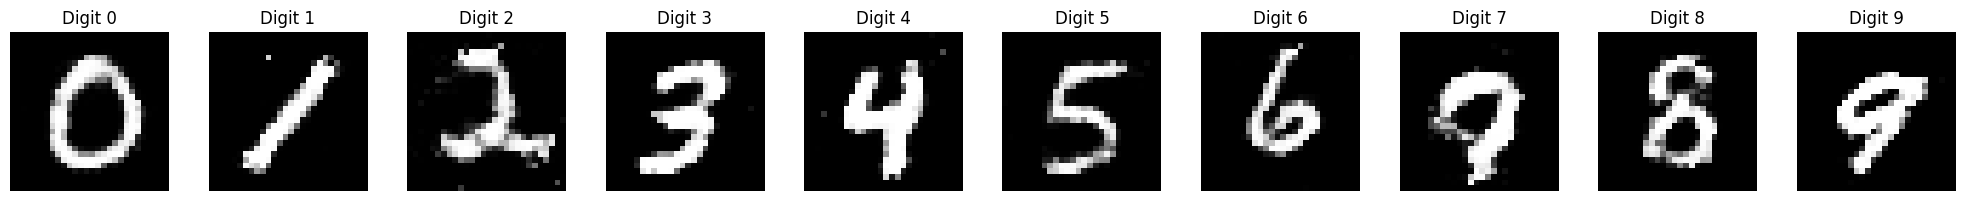

In [ ]:
print("\nGenerating sample conditioned images (one per class 0-9)...")
G.eval() # Set to evaluation mode
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

for i in range(10):
    z = torch.randn(1, latent_dim).to(device)
    label = torch.tensor([i]).to(device)

    with torch.no_grad():
        fake = G(z, label)

    img = fake.view(28, 28).cpu().numpy()
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f"Digit {i}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()